# Publication-Ready Figure: Run-to-Run Reproducibility Audit (Chapter 5, §5.3)

Reads `run_summary.json` directly from the run directories of the DELCODE-only
stabilised Brain-TokenGT repeat audit (`BRAINTOKENGT/outputs/braintokengt-delcode-whole-
brain-repaired-fix-stabilized*`, 19 runs across 4 seeds) and the DELCODE-only no-encoder
c{GELSTM} configuration (`CLASSIFIER/outputs/recon-ablation-gelstm-none*`, whose seed-42
directory holds 5 runs across 4 different git commits). No number here is recomputed
independently of these summaries.

1. **Figure 8: Run-to-Run Reproducibility Audit** (`fig8_btgt_reproducibility_audit.pdf`)


In [1]:
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Global publication style settings (.claude/rules/plots.md)
plt.rcParams.update({
    'font.family': 'Courier New',
    'font.size': 8,
    'axes.labelsize': 8.5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

MM = 1 / 25.4

# Two-hue Teal / Purple publication palette (consistent with the rest of the thesis)
COLOR_GELSTM_FILL, COLOR_GELSTM_EDGE = '#2ba099', '#14605b'      # Teal
COLOR_BTGT_FILL, COLOR_BTGT_EDGE = '#873397', '#50165b'          # Purple

_REPO_ROOT = Path(__file__).resolve().parents[2] if '__file__' in globals() else Path(os.getcwd() if not os.getcwd().endswith('plots_notebooks') else Path(os.getcwd()).parents[1])
CLASSIFIER_ROOT = _REPO_ROOT / 'CLASSIFIER'
BRAINTOKENGT_ROOT = _REPO_ROOT / 'BRAINTOKENGT'
OUTPUT_DIRS = [
    _REPO_ROOT / 'THESIS' / 'figures',
    _REPO_ROOT / 'DOCS' / 'results' / 'figures',
]
for d in OUTPUT_DIRS:
    d.mkdir(parents=True, exist_ok=True)

print('✓ Environment initialized and output directories ready.')


✓ Environment initialized and output directories ready.


## Ingest: Brain-TokenGT repeat runs

Every `run_summary.json` under the four stabilised-configuration experiment directories,
held-out `test_auc`, grouped by seed. One run directory
(`tidal-ember-6-...`) has no `run_summary.json` (still running / never completed), which
is why 19 summaries are read from 20 run directories, matching "nineteen repeat runs"
in the prose.


In [2]:
BTGT_SEED_DIRS = {
    42: BRAINTOKENGT_ROOT / 'outputs' / 'braintokengt-delcode-whole-brain-repaired-fix-stabilized',
    43: BRAINTOKENGT_ROOT / 'outputs' / 'braintokengt-delcode-whole-brain-repaired-fix-stabilized-seed43',
    44: BRAINTOKENGT_ROOT / 'outputs' / 'braintokengt-delcode-whole-brain-repaired-fix-stabilized-seed44',
    45: BRAINTOKENGT_ROOT / 'outputs' / 'braintokengt-delcode-whole-brain-repaired-fix-stabilized-seed45',
}

btgt_records = []
for seed, base in BTGT_SEED_DIRS.items():
    for run_dir in sorted((base / 'runs').iterdir()):
        p = run_dir / 'run_summary.json'
        if not p.is_file():
            print(f'  [skip] {run_dir.name}: no run_summary.json (never completed)')
            continue
        d = json.loads(p.read_text())
        btgt_records.append({'seed': seed, 'run': run_dir.name, 'test_auc': d['test_auc']})

btgt_df = pd.DataFrame(btgt_records)
print(f"✓ {len(btgt_df)} Brain-TokenGT repeat runs loaded across {btgt_df['seed'].nunique()} seeds.")
btgt_df.groupby('seed')['test_auc'].agg(['count', 'min', 'max', lambda s: s.max() - s.min()]).rename(
    columns={'<lambda_0>': 'range'})


  [skip] tidal-ember-6-5e33e2170-2026-08-21_12-34-07: no run_summary.json (never completed)
✓ 19 Brain-TokenGT repeat runs loaded across 4 seeds.


,count,min,max,range
seed,,,,
42,7,0.357143,0.707792,0.350649
43,4,0.577922,0.818182,0.240260
44,4,0.415584,0.623377,0.207792
45,4,0.519481,0.733766,0.214286


## Ingest: no-encoder GELSTM repeat/reproducibility runs

Seed 42 has 5 run directories spanning 4 different git commits (2026-08-17 to
2026-08-23) -- this is the bit-reproducibility check described in §5.3, run repeatedly
across code changes rather than a single-run artefact. Seeds 43, 44 and 45 each have one
run directory available.


In [3]:
GELSTM_NONE_SEED_DIRS = {
    42: CLASSIFIER_ROOT / 'outputs' / 'recon-ablation-gelstm-none',
    43: CLASSIFIER_ROOT / 'outputs' / 'recon-ablation-gelstm-none-seed43',
    44: CLASSIFIER_ROOT / 'outputs' / 'recon-ablation-gelstm-none-seed44',
    45: CLASSIFIER_ROOT / 'outputs' / 'recon-ablation-gelstm-none-seed45',
}

gelstm_records = []
for seed, base in GELSTM_NONE_SEED_DIRS.items():
    for run_dir in sorted((base / 'runs').iterdir()):
        p = run_dir / 'run_summary.json'
        if not p.is_file():
            continue
        d = json.loads(p.read_text())
        gelstm_records.append({'seed': seed, 'run': run_dir.name, 'test_auc': d['test_auc'],
                                'git_commit': d.get('git', {}).get('commit')})

gelstm_df = pd.DataFrame(gelstm_records)
print(f"✓ {len(gelstm_df)} no-encoder GELSTM runs loaded across {gelstm_df['seed'].nunique()} seeds.")
gelstm_df.groupby('seed')['test_auc'].agg(['count', 'nunique', 'min', 'max'])


✓ 8 no-encoder GELSTM runs loaded across 4 seeds.


,count,nunique,min,max
seed,,,,
42,5,1,0.760714,0.760714
43,1,1,0.864286,0.864286
44,1,1,0.821429,0.821429
45,1,1,0.878571,0.878571


### Cross-check against `tab:rq2-encoder` and §5.3


In [4]:
# Seed-42 repeats: exact bit-reproducibility (zero within-seed spread across 4 code revisions).
_seed42 = gelstm_df[gelstm_df['seed'] == 42]
assert _seed42['test_auc'].nunique() == 1, 'seed-42 no-encoder GELSTM repeats are not bit-identical'
assert _seed42['git_commit'].nunique() >= 2, 'expected repeats across at least 2 distinct git commits'
print(f"✓ All {len(_seed42)} seed-42 runs across {_seed42['git_commit'].nunique()} distinct git commits "
      f"give test_auc={_seed42['test_auc'].iloc[0]:.10f} to the last recorded digit.")

# Per-seed means/SD against tab:rq2-encoder's 'None' row (0.8313 +/- 0.0529, n=4 seeds).
_per_seed_mean = gelstm_df.groupby('seed')['test_auc'].mean()
_mean, _sd = _per_seed_mean.mean(), _per_seed_mean.std(ddof=1)
assert abs(_mean - 0.8313) < 5e-4, f'no-encoder mean {_mean:.4f} vs table 0.8313'
assert abs(_sd - 0.0529) < 5e-4, f'no-encoder SD {_sd:.4f} vs table 0.0529'
print(f'✓ Cross-seed mean {_mean:.4f} +/- {_sd:.4f} matches tab:rq2-encoder \'None\' row (0.8313 +/- 0.0529).')


✓ All 5 seed-42 runs across 3 distinct git commits give test_auc=0.7607142857 to the last recorded digit.
✓ Cross-seed mean 0.8313 +/- 0.0529 matches tab:rq2-encoder 'None' row (0.8313 +/- 0.0529).


## Figure 8: Run-to-run reproducibility audit

One column per seed. Purple: the 19 Brain-TokenGT repeat runs (jittered strip, same
setting including the seed). Teal: the no-encoder c{GELSTM} runs -- 5 runs across 4
code revisions at seed 42, single runs at seeds 43-45 -- all landing on one value per
seed rather than scattering.


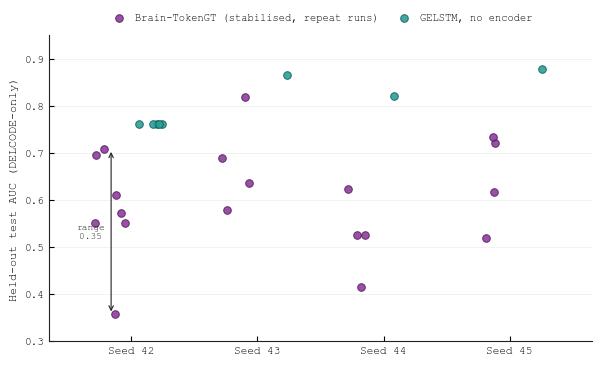

✓ Figure 8 saved successfully.


In [5]:
rng = np.random.default_rng(0)
seeds = [42, 43, 44, 45]
x_base = {s: i for i, s in enumerate(seeds)}

fig, ax = plt.subplots(figsize=(150 * MM, 90 * MM))

for s in seeds:
    sub = btgt_df[btgt_df['seed'] == s]
    jitter = rng.uniform(-0.13, 0.13, size=len(sub))
    ax.scatter(x_base[s] - 0.16 + jitter, sub['test_auc'], s=30, color=COLOR_BTGT_FILL,
               edgecolor=COLOR_BTGT_EDGE, linewidth=0.7, alpha=0.85, zorder=3,
               label='Brain-TokenGT (stabilised, repeat runs)' if s == seeds[0] else None)

    sub_g = gelstm_df[gelstm_df['seed'] == s]
    jitter_g = rng.uniform(-0.10, 0.10, size=len(sub_g))
    ax.scatter(x_base[s] + 0.16 + jitter_g, sub_g['test_auc'], s=30, color=COLOR_GELSTM_FILL,
               edgecolor=COLOR_GELSTM_EDGE, linewidth=0.7, alpha=0.9, zorder=3,
               label='GELSTM, no encoder' if s == seeds[0] else None)

# Annotate the seed-42 BTGT range explicitly -- the section's central claim.
_s42 = btgt_df[btgt_df['seed'] == 42]['test_auc']
ax.annotate('', xy=(0 - 0.16, _s42.max()), xytext=(0 - 0.16, _s42.min()),
            arrowprops=dict(arrowstyle='<->', color='#222222', linewidth=0.8), zorder=6)
ax.text(0 - 0.32, (_s42.max() + _s42.min()) / 2, f'range\n{_s42.max() - _s42.min():.2f}',
        ha='center', va='center', fontsize=6.8, color='#222222')

ax.set_xticks(list(x_base.values()))
ax.set_xticklabels([f'Seed {s}' for s in seeds])
ax.set_xlim(-0.65, 3.65)
ax.set_ylabel('Held-out test AUC (DELCODE-only)')
ax.set_ylim(0.30, 0.95)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')
ax.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, fontsize=7.5,
          handletextpad=0.5, columnspacing=1.5)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig8_btgt_reproducibility_audit.pdf', facecolor='white', edgecolor='none')
    fig.savefig(out_dir / 'fig8_btgt_reproducibility_audit.png', dpi=600, facecolor='white', edgecolor='none')

plt.show()
print('✓ Figure 8 saved successfully.')
